In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


## Step 1 — Load the Dataset

The Heart Disease dataset contains several numerical and categorical features.
For PCA, we will use selected numerical features because PCA requires numerical input.


In [3]:
df =pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Step 2 — Select Features and Scale the Data

We selected six numerical features for PCA:

* `Age`
* `RestingBP`
* `Cholesterol`
* `FastingBS`
* `MaxHR`
* `Oldpeak`

These features have different scales, so we use `StandardScaler` before applying PCA. Scaling is important because PCA is based on variance, and features with larger numerical ranges could otherwise have a greater influence on the results.


In [4]:
clustering_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
]

X_cluster = df[clustering_features]

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

## Step 3 — Apply PCA

We first apply PCA without specifying the number of components. This allows us to examine how much variance each principal component explains.


In [6]:
pca = PCA()

X_pca_full = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.3026669  0.21240626 0.14739457 0.13564588 0.1095916  0.0922948 ]


The explained variance ratios show how much of the total variance is captured by each principal component.

The first component explains approximately **30.27%** of the variance, while the second explains approximately **21.24%**.

The remaining variance is distributed across the other components.


## Step 4 — Calculate Cumulative Explained Variance

Cumulative explained variance shows how much total variance is retained when multiple principal components are combined.

This helps us determine how many components are needed to retain approximately **95%** of the original variance.


In [7]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.3026669  0.51507315 0.66246772 0.7981136  0.9077052  1.        ]


cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

The cumulative explained variance increases as more principal components are added.

After five components, approximately **90.77%** of the variance is retained. Therefore, five components are not enough to reach the 95% target.


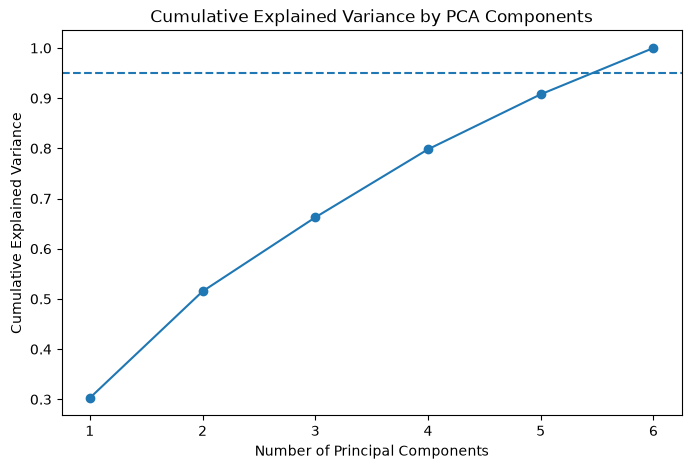

In [9]:

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance by PCA Components")

plt.show()

## Step 5 — Choose the Number of Components

We find the minimum number of principal components required to retain at least 95% of the total variance.


In [10]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Number of components for 95% variance:", n_components_95)

Number of components for 95% variance: 6


The result shows that **6 components** are required to retain at least 95% of the variance.

Since the original dataset contains only six selected features, PCA does not actually reduce the dimensionality at the 95% variance threshold.


In [11]:
n_components_95 = 6

pca_95 = PCA(
    n_components=n_components_95
)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca_95.shape)

Original shape: (918, 6)
Reduced shape: (918, 6)


All six components are retained, so the transformed data keeps **100% of the original variance**.

The shape also remains `(918, 6)`, confirming that there is no dimensionality reduction when keeping enough components for the 95% variance target.


In [12]:
print(
    "Variance retained:",
    pca_95.explained_variance_ratio_.sum()
)

Variance retained: 1.0


## Step 6 — Reduce the Data to 2 Components

For visualization, we reduce the data to two principal components.

This allows us to represent the six-dimensional data in a 2D plot while keeping the directions with the highest variance.


In [13]:
pca_2d = PCA(
    n_components=2
)

X_pca_2d = pca_2d.fit_transform(X_scaled)

X_pca_2d.shape

(918, 2)

The first two principal components explain approximately **51.51%** of the total variance.

Therefore, the 2D representation provides a useful visualization of the dataset, but it does not preserve all of the information contained in the original six features.


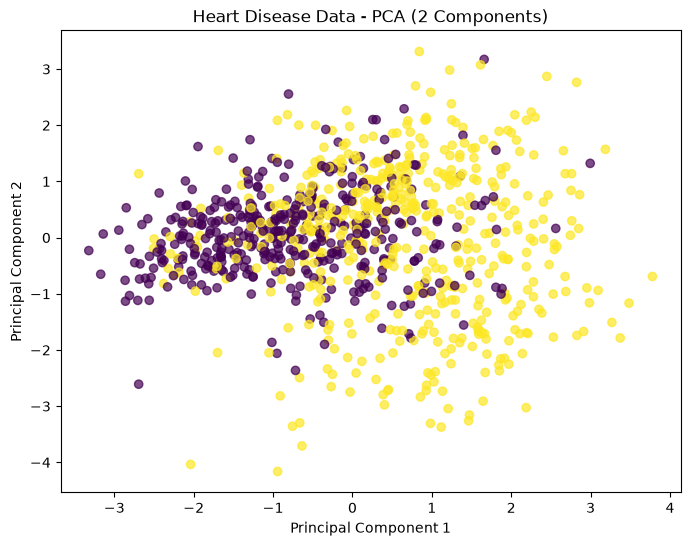

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=df["HeartDisease"],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Heart Disease Data - PCA (2 Components)")

plt.show()

### Interpretation

The 2D PCA plot allows us to visualize the Heart Disease dataset using only two principal components.

The points are colored according to `HeartDisease` to help us visually inspect whether the two groups show any separation.

However, PCA is an **unsupervised technique**, so it does not use the `HeartDisease` target when creating the principal components. The coloring is only used to interpret the resulting visualization.


## Step 7 — What PCA Preserved

* PCA preserved the directions with the highest variance in the data.
* The first two components retained approximately **51.51%** of the total variance.
* Six components were required to retain at least **95%** of the variance.
* PCA provided a 2D representation that makes the high-dimensional data easier to visualize.


## What PCA Cost

* The original features are transformed into combinations called principal components.
* The new components are less directly interpretable than the original features.
* Using only two components loses approximately **48.49%** of the total variance.
* At the 95% variance threshold, PCA did not reduce the number of dimensions because all six components were needed.


## Conclusion

PCA successfully transformed the standardized numerical features into principal components and allowed the dataset to be visualized in two dimensions.

However, for this dataset, PCA did not provide actual dimensionality reduction at the **95% variance threshold**, because all six components were required.

The main benefit of PCA in this case is the **2D visualization**, while the main trade-off is the loss of direct interpretability of the original features.
